In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
fact_res = pd.read_csv("fact_res.csv")


In [5]:
dim_date = pd.read_csv("dim_date.csv")


In [7]:

dim_service = pd.read_csv("dim_service.csv")


In [9]:
fact_serviceP = pd.read_csv("fact_serviceP.csv")

In [11]:

dim_eval = pd.read_csv("dim_eval.csv")

In [13]:

dim_provider= pd.read_csv('dim_provider.csv', sep=";", encoding ='latin1')

In [15]:
fact_res.head()

,Date_FK,id_event_FK,id_service_FK,id_status_FK,id_evaluation_FK
0,9328,6879,819,1,9006
1,8491,6547,575,1,6472
2,9454,4505,2059,2,-1
3,8040,986,614,1,-1
4,8798,3677,361,2,11044


In [17]:
dim_date.head()


,Date_key,Date,Month,Year,Day
0,1,2000-01-01,1,2000,1
1,2,2000-01-02,1,2000,2
2,3,2000-01-03,1,2000,3
3,4,2000-01-04,1,2000,4
4,5,2000-01-05,1,2000,5


In [19]:
dim_service.head()


,id_service,description,title,codeService
0,1,Understand usually available experience program.,Brand Activation Events,S1
1,10,Leg among reach before. Alone professional app...,Unspecified,S10
2,100,Sometimes us teacher spend to. Factor help can.,Risk Management for Events,S100
3,1000,Leg here people great garden key.,Event Insurance Coordination,S1000
4,1001,Campaign open report. To PM try professional i...,Green Event Planning,S1001


In [21]:
fact_serviceP.head()


,price,id_providerFK,id_subcategoryFK,id_serviceFK
0,5662,322,3,1
1,4821,428,1,2
2,846,737,2,3
3,7626,671,3,4
4,3805,33,4,5


In [23]:
dim_provider.head()


,"id_provider,name,city,service_type,codeP"
0,"1,Cooper-Lloyd,Jendouba,Decoration,P1"
1,"2,Andrews, Hart and Smith,Kébili,Decoration,P2"
2,"3,Gutierrez LLC,Kairouan,Decoration,P3"
3,"4,Riggs-Gray,Siliana,Decoration,P4"
4,"5,Parker-Lowe,Tataouine,Decoration,P5"


In [25]:
dim_eval.head()

,id_evaluation,rating,codeEval
0,1,Bad,Evalu1
1,2,Good,Evalu2
2,3,Bad,Evalu3
3,4,Bad,Evalu4
4,5,Bad,Evalu5


In [40]:
fact_res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Date_FK           18000 non-null  int64
 1   id_event_FK       18000 non-null  int64
 2   id_service_FK     18000 non-null  int64
 3   id_status_FK      18000 non-null  int64
 4   id_evaluation_FK  18000 non-null  int64
dtypes: int64(5)
memory usage: 703.3 KB


In [42]:
fact_res.describe()

,Date_FK,id_event_FK,id_service_FK,id_status_FK,id_evaluation_FK
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,8764.892500,5928.737778,1251.273833,2.001222,2991.865444
std,421.597152,3458.678475,723.674157,0.815701,3942.696862
min,8037.000000,0.000000,1.000000,1.000000,-1.000000
25%,8400.000000,2935.750000,626.750000,1.000000,-1.000000
50%,8762.000000,5904.000000,1242.000000,2.000000,-1.000000
75%,9129.000000,8944.250000,1882.000000,3.000000,6043.500000
max,9497.000000,11957.000000,2500.000000,3.000000,12000.000000


In [44]:
fact_res.isnull().sum()

Date_FK             0
id_event_FK         0
id_service_FK       0
id_status_FK        0
id_evaluation_FK    0
dtype: int64

In [46]:
dim_date.isnull().sum()


Date_key    0
Date        0
Month       0
Year        0
Day         0
dtype: int64

In [48]:
dim_service.isnull().sum()


id_service     0
description    0
title          0
codeService    0
dtype: int64

In [50]:
fact_serviceP.isnull().sum()


price               0
id_providerFK       0
id_subcategoryFK    0
id_serviceFK        0
dtype: int64

In [58]:
dim_provider.isnull().sum()


id_provider,name,city,service_type,codeP    0
dtype: int64

In [60]:
dim_eval.isnull().sum()

id_evaluation    0
rating           0
codeEval         0
dtype: int64

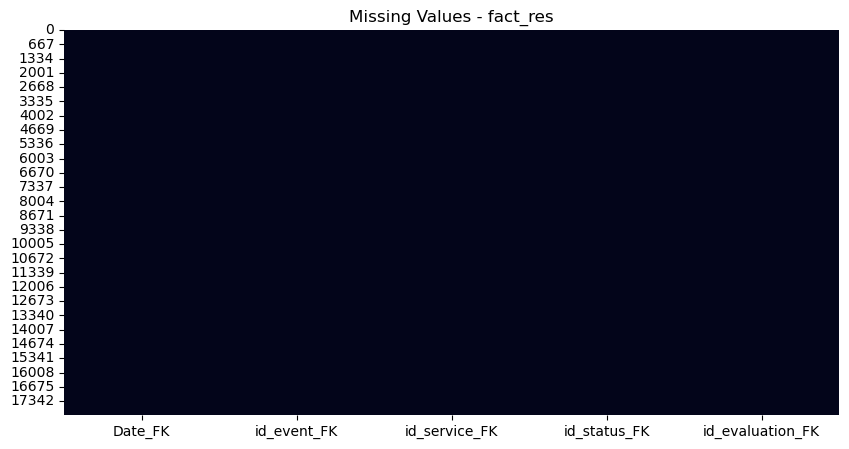

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(fact_res.isnull(), cbar=False)
plt.title("Missing Values - fact_res")
plt.show()

In [66]:
fact_res.columns

Index(['Date_FK', 'id_event_FK', 'id_service_FK', 'id_status_FK',
       'id_evaluation_FK'],
      dtype='object')

In [68]:
fact_serviceP.columns

Index(['price', 'id_providerFK', 'id_subcategoryFK', 'id_serviceFK'], dtype='object')

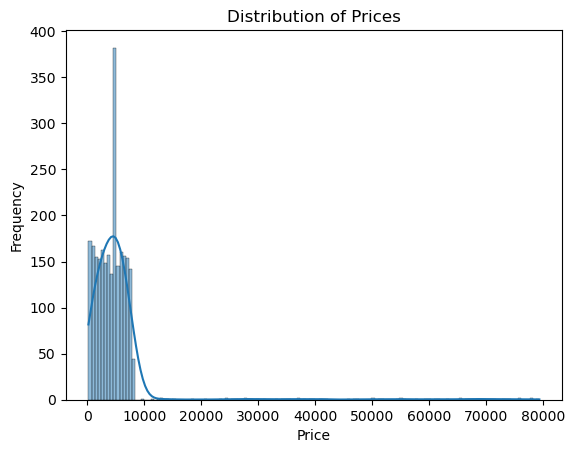

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(fact_serviceP['price'], kde=True)
plt.title("Distribution of Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

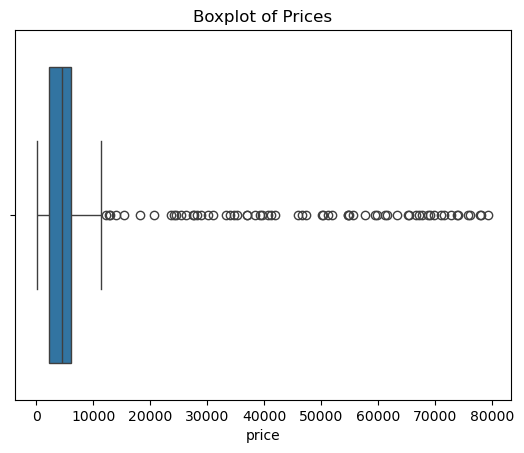

In [31]:
sns.boxplot(x=fact_serviceP['price'])
plt.title("Boxplot of Prices")
plt.show()

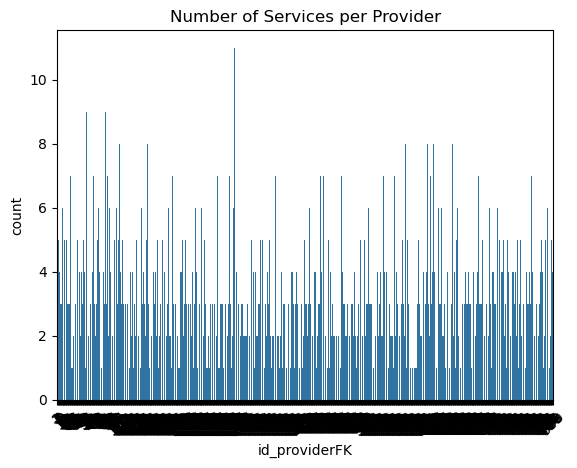

In [33]:
sns.countplot(x='id_providerFK', data=fact_serviceP)
plt.title("Number of Services per Provider")
plt.xticks(rotation=45)
plt.show()

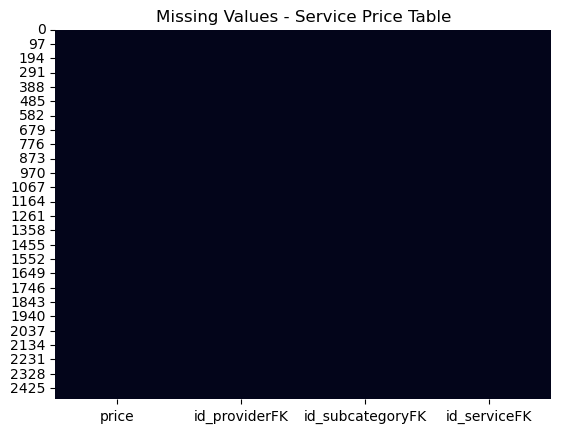

In [35]:
sns.heatmap(fact_serviceP.isnull(), cbar=False)
plt.title("Missing Values - Service Price Table")
plt.show()

In [86]:
fact_res.columns

Index(['Date_FK', 'id_event_FK', 'id_service_FK', 'id_status_FK',
       'id_evaluation_FK'],
      dtype='object')

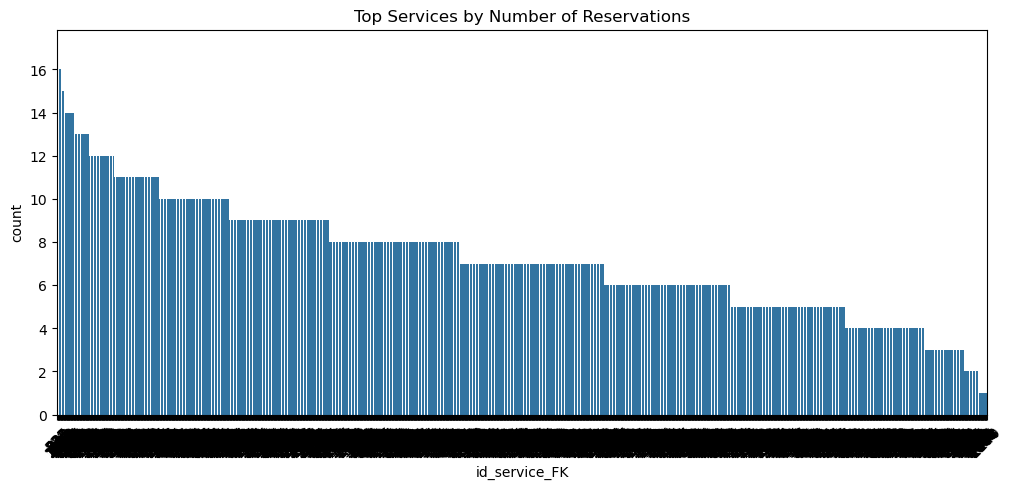

In [39]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='id_service_FK',
    data=fact_res,
    order=fact_res['id_service_FK'].value_counts().index
)

plt.title("Top Services by Number of Reservations")
plt.xticks(rotation=45)
plt.show()

In [94]:
dim_date.columns

Index(['Date_key', 'Date', 'Month', 'Year', 'Day'], dtype='object')

In [40]:
merged = fact_res.merge(
    dim_date,
    left_on='Date_FK',
    right_on='Date_key'
)

In [100]:
merged.head()

,Date_FK,id_event_FK,id_service_FK,id_status_FK,id_evaluation_FK,Date_key,Date,Month,Year,Day
0,9328,6879,819,1,9006,9328,2025-07-15,7,2025,15
1,8491,6547,575,1,6472,8491,2023-03-31,3,2023,31
2,9454,4505,2059,2,-1,9454,2025-11-18,11,2025,18
3,8040,986,614,1,-1,8040,2022-01-04,1,2022,4
4,8798,3677,361,2,11044,8798,2024-02-01,2,2024,1


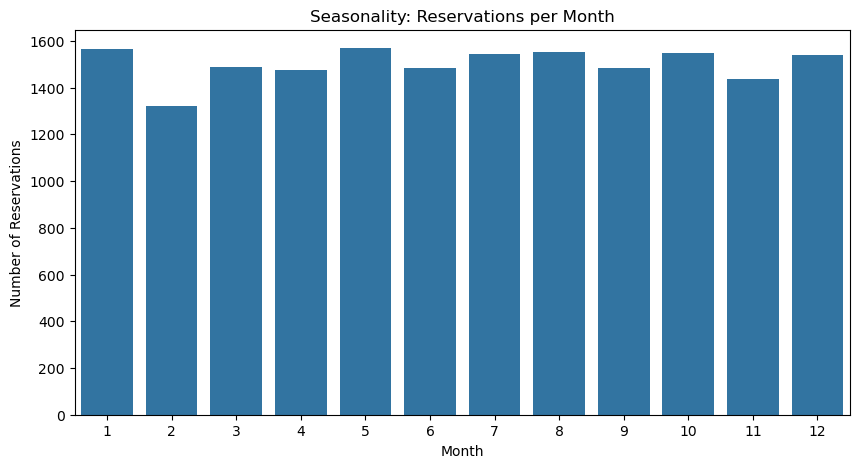

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    x='Month',
    data=merged,
    order=sorted(merged['Month'].unique())
)

plt.title("Seasonality: Reservations per Month")
plt.xlabel("Month")
plt.ylabel("Number of Reservations")
plt.show()

In [45]:
fact_res.columns = fact_res.columns.str.strip()
dim_date.columns = dim_date.columns.str.strip()
dim_service.columns = dim_service.columns.str.strip()
fact_serviceP.columns = fact_serviceP.columns.str.strip()
dim_provider.columns = dim_provider.columns.str.strip()
dim_eval.columns = dim_eval.columns.str.strip()

In [47]:
# merge date
df = fact_res.merge(dim_date, left_on='Date_FK', right_on='Date_key')



In [49]:

# merge service (nom du service)
df = df.merge(dim_service, left_on='id_service_FK', right_on='id_service')



In [114]:
fact_serviceP.columns

Index(['price', 'id_providerFK', 'id_subcategoryFK', 'id_serviceFK'], dtype='object')

In [51]:
df = df.merge(
    fact_serviceP,
    left_on='id_service_FK',
    right_on='id_serviceFK'
)

In [53]:
demand_df = df.groupby(['id_service_FK', 'Month']).size().reset_index(name='demand')

In [55]:
df_ml = df.merge(demand_df, on=['id_service_FK', 'Month'])

In [128]:
df_ml.columns

Index(['Date_FK', 'id_event_FK', 'id_service_FK', 'id_status_FK',
       'id_evaluation_FK', 'Date_key', 'Date', 'Month', 'Year', 'Day',
       'id_service', 'description', 'title', 'codeService', 'price',
       'id_providerFK', 'id_subcategoryFK', 'id_serviceFK', 'demand'],
      dtype='object')

In [57]:
demand_df = df.groupby(['id_service_FK', 'Month']).size().reset_index(name='demand')

In [59]:
df = df.merge(demand_df, on=['id_service_FK', 'Month'])

In [61]:
print(df[['id_service_FK', 'Month', 'demand']].head())

   id_service_FK  Month  demand
0            819      7       1
1            575      3       1
2           2059     11       2
3            614      1       1
4            361      2       2


In [63]:
dataset_ml = df[[
    'price',
    'title',
    'Month',
    'demand'
]]

In [65]:
df_backup = df.copy()

In [67]:
df_ml.head()


,Date_FK,id_event_FK,id_service_FK,id_status_FK,id_evaluation_FK,Date_key,Date,Month,Year,Day,id_service,description,title,codeService,price,id_providerFK,id_subcategoryFK,id_serviceFK,demand
0,9328,6879,819,1,9006,9328,2025-07-15,7,2025,15,819,Up too now will. Another top six guy. Art cust...,Risk Management for Events,S819,4180,288,4,819,1
1,8491,6547,575,1,6472,8491,2023-03-31,3,2023,31,575,Do might community image. Professor best night...,Event Security Management,S575,6279,792,4,575,1
2,9454,4505,2059,2,-1,9454,2025-11-18,11,2025,18,2059,Speak let food choice popular.,Corporate Training Events,S2059,789,225,4,2059,2
3,8040,986,614,1,-1,8040,2022-01-04,1,2022,4,614,Together recently crime. Wrong walk time herself.,Festival Planning & Coordination,S614,4580,776,1,614,1
4,8798,3677,361,2,11044,8798,2024-02-01,2,2024,1,361,Beat start present north senior out identify.,Event Branding Services,S361,3013,688,4,361,2


In [69]:
df_ml.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date_FK           18000 non-null  int64 
 1   id_event_FK       18000 non-null  int64 
 2   id_service_FK     18000 non-null  int64 
 3   id_status_FK      18000 non-null  int64 
 4   id_evaluation_FK  18000 non-null  int64 
 5   Date_key          18000 non-null  int64 
 6   Date              18000 non-null  object
 7   Month             18000 non-null  int64 
 8   Year              18000 non-null  int64 
 9   Day               18000 non-null  int64 
 10  id_service        18000 non-null  int64 
 11  description       18000 non-null  object
 12  title             18000 non-null  object
 13  codeService       18000 non-null  object
 14  price             18000 non-null  int64 
 15  id_providerFK     18000 non-null  int64 
 16  id_subcategoryFK  18000 non-null  int64 
 17  id_serviceFK

In [150]:
df_ml.isnull().sum()

Date_FK             0
id_event_FK         0
id_service_FK       0
id_status_FK        0
id_evaluation_FK    0
Date_key            0
Date                0
Month               0
Year                0
Day                 0
id_service          0
description         0
title               0
codeService         0
price               0
id_providerFK       0
id_subcategoryFK    0
id_serviceFK        0
demand              0
dtype: int64

In [77]:
pip install xgboost

In [79]:
from xgboost import XGBRegressor

In [119]:
demand_df = df.groupby(['id_service_FK', 'Month']).size().reset_index(name='demand')
df = df.merge(demand_df, on=['id_service_FK', 'Month'])

In [121]:
df_ml = df[['price', 'title', 'Month', 'demand']].copy()

In [123]:
df_ml = pd.get_dummies(df_ml, columns=['title', 'Month'], drop_first=True)

In [125]:
X = df_ml.drop('demand', axis=1)
y = df_ml['demand']

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [129]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [131]:
y_pred = xgb.predict(X_test)

In [133]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 0.7089275410889355
R2: 0.12275242805480957


In [177]:
from sklearn.ensemble import RandomForestRegressor

In [179]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

In [183]:
X_train.dtypes

price      int64
title     object
Month      int64
rating    object
dtype: object

In [185]:
X_train['rating'] = pd.to_numeric(X_train['rating'], errors='coerce')
X_test['rating'] = pd.to_numeric(X_test['rating'], errors='coerce')

In [187]:
X_train = pd.get_dummies(X_train, columns=['title'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['title'], drop_first=True)

In [189]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [191]:
print(X_train.dtypes)

price                                        int64
Month                                        int64
rating                                     float64
title_Annual General Meeting Management       bool
title_Audio & Visual Setup Service            bool
                                            ...   
title_VIP Guest Handling Service              bool
title_Venue Selection & Booking               bool
title_Virtual Event Production                bool
title_Wedding Coordination Service            bool
title_Workshop Planning Service               bool
Length: 89, dtype: object


In [193]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [195]:
y_pred_rf = rf.predict(X_test)

In [197]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

RMSE: 0.729273343447527
R2: 0.07167700670328725


In [199]:
print("=== COMPARISON ===")
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

=== COMPARISON ===
XGBoost R2: 0.09427231550216675
Random Forest R2: 0.07167700670328725


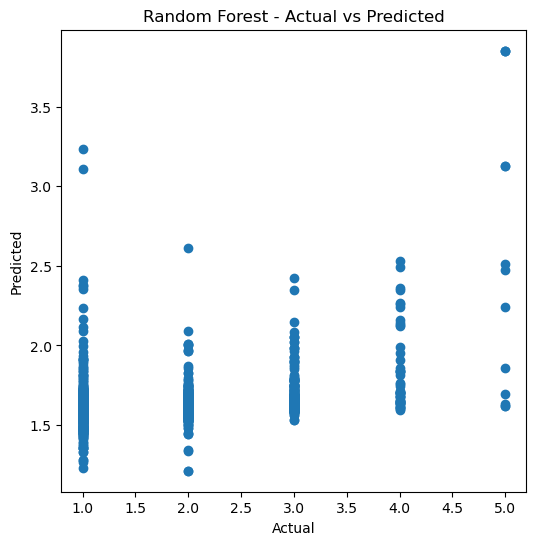

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

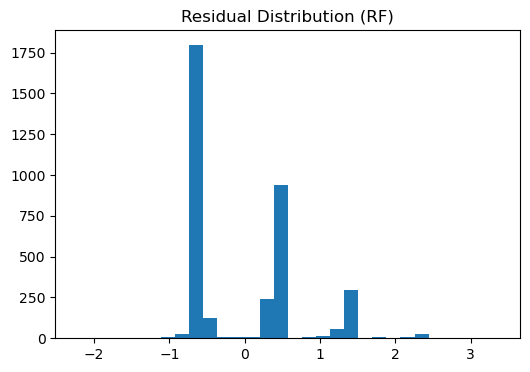

In [203]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution (RF)")
plt.show()

In [205]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(10))

                                   feature  importance
0                                    price    0.465979
1                                    Month    0.339968
7      title_Catering Coordination Service    0.016281
76  title_Startup Pitch Event Organization    0.010878
82                       title_Unspecified    0.010552
31         title_Event Feedback Collection    0.009010
51            title_Host & MC Coordination    0.008915
11        title_Community Event Management    0.007349
43      title_Executive Event Coordination    0.007336
45  title_Festival Planning & Coordination    0.006719
